# Sweden C strategy runner

Notebook pour lancer la variante **C = best_plus_regime_filter**, inspecter ses parametres, afficher les metriques principales et tracer les graphes de performance.

La logique est importee depuis les scripts existants. Le notebook ne retune rien et ne modifie pas le moteur core.

In [14]:
from pathlib import Path
import json
import logging
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'scripts' / 'run_sweden_filter_ablation_campaign.py').exists():
            return candidate
    raise FileNotFoundError('Could not locate project root from the current notebook directory.')


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

pd.set_option('display.max_columns', 160)
pd.set_option('display.width', 220)
plt.style.use('seaborn-v0_8-whitegrid')

logging.basicConfig(level=logging.INFO, format='%(asctime)s | %(levelname)s | %(message)s')
print(f'Project root: {PROJECT_ROOT}')

import plotly.io as pio
pio.renderers.default = "notebook_connected"

Project root: D:\Business\Trading\VSCODE\algo-trading-stat-arb-terminal


In [15]:
from scripts.run_sweden_edge_decomposition_campaign import (
    ASSET_REGISTRY_PATH,
    BASE_SELECTION_MODE,
    BASE_SELECTION_VARIANT,
    DATA_PATH,
    UNIVERSE,
    build_universe_assets,
    load_or_build_scans,
)
from scripts.run_sweden_filter_ablation_campaign import (
    FilterThresholds,
    build_ablation_configs,
    build_concentration_comparison,
    build_trade_level_comparison,
    config_to_dict,
    derive_filter_thresholds,
    find_reference_output,
    run_config,
)
from utils.edge_decomposition import (
    REGIME_RULES_DESCRIPTION,
    build_pair_level_summary,
    build_trade_diagnostics,
    compute_market_regime_features,
    load_price_panel,
    summarize_edge_by_segment,
)

print('Imports OK')

Imports OK


## Parametres du run

Modifie cette cellule si tu veux relancer C sur une autre fenetre ou forcer une reconstruction des scans.

In [16]:
CONFIG_NAME = 'best_plus_regime_filter'  # Variante C
START = '2018-01-01'
END = '2025-12-31'

REBUILD_SCANS = False
SAVE_OUTPUTS = True

# Si disponible, ce dossier fournit les seuils exacts de l'ablation precedente.
ABLATION_OUTPUT = PROJECT_ROOT / 'data' / 'experiments' / 'sweden_filter_ablation_20180101_20251231_20260418_224839'
REFERENCE_OUTPUT = None  # fallback: dernier dossier sweden_edge_decomposition_* compatible

OUTPUT_DIR = PROJECT_ROOT / 'data' / 'experiments' / 'notebook_sweden_C_strategy_run'

# Le cache de scans hebdo existant commence au premier vendredi 2018-01-05.
# Le backtest reste lance a START, ce parametre ne sert qu'a eviter de reconstruire le cache.
SCAN_CACHE_LOAD_START = '2018-01-05' if pd.Timestamp(START) <= pd.Timestamp('2018-01-05') else START

print({
    'config': CONFIG_NAME,
    'start': START,
    'end': END,
    'scan_cache_load_start': SCAN_CACHE_LOAD_START,
    'rebuild_scans': REBUILD_SCANS,
})

{'config': 'best_plus_regime_filter', 'start': '2018-01-01', 'end': '2025-12-31', 'scan_cache_load_start': '2018-01-05', 'rebuild_scans': False}


In [17]:
def load_thresholds() -> tuple[FilterThresholds, dict]:
    if ABLATION_OUTPUT.exists() and (ABLATION_OUTPUT / 'metadata.json').exists():
        meta = json.loads((ABLATION_OUTPUT / 'metadata.json').read_text(encoding='utf-8'))
        t = meta.get('thresholds', {})
        thresholds = FilterThresholds(
            abs_z_extreme_min=float(t['abs_z_extreme_min']),
            zspeed_ewma_extreme_min=float(t['zspeed_ewma_extreme_min']),
            beta_stability_degraded_min=float(t['beta_stability_degraded_min']),
            source_dir=ABLATION_OUTPUT,
        )
        return thresholds, meta

    reference_dir = find_reference_output(PROJECT_ROOT / 'data' / 'experiments', REFERENCE_OUTPUT)
    thresholds = derive_filter_thresholds(reference_dir)
    meta_path = reference_dir / 'metadata.json'
    meta = json.loads(meta_path.read_text(encoding='utf-8')) if meta_path.exists() else {}
    return thresholds, meta


thresholds, threshold_meta = load_thresholds()
configs = build_ablation_configs()
config = next(c for c in configs if c.name == CONFIG_NAME)

display(Markdown('### Variante C'))
display(pd.DataFrame([config_to_dict(config)]).T.rename(columns={0: 'value'}))

display(Markdown('### Seuils repris sans retuning'))
display(pd.DataFrame([
    {'threshold': 'abs_z_extreme_min', 'value': thresholds.abs_z_extreme_min},
    {'threshold': 'zspeed_ewma_extreme_min', 'value': thresholds.zspeed_ewma_extreme_min},
    {'threshold': 'beta_stability_degraded_min', 'value': thresholds.beta_stability_degraded_min},
    {'threshold': 'source_dir', 'value': str(thresholds.source_dir)},
]))

display(Markdown('### Regime rules'))
display(Markdown(REGIME_RULES_DESCRIPTION))

### Variante C

,value
name,best_plus_regime_filter
label,best_plus_regime_filter
letter,C
role,h1_regime
z_entry,1.8
z_window,60
z_exit,0.6
z_stop,3.6
max_holding_days,30
entry_mode,entry_zspeed_ewma_cap


### Seuils repris sans retuning

,threshold,value
0,abs_z_extreme_min,3.14406
1,zspeed_ewma_extreme_min,0.933395
2,beta_stability_degraded_min,0.221501
3,source_dir,D:\Business\Trading\VSCODE\algo-trading-stat-a...


### Regime rules

stress_regime = market_vol_20d above its expanding 75th percentile computed with one-day lag and min_history observations; trending_regime = abs(market_return_20d) above its expanding 75th percentile computed with one-day lag and min_history observations; neutral_regime = not stress and not trending. These rules use only history available before each date.

## Chargement des scans, prix et regimes de marche

In [18]:
scans = load_or_build_scans(start=SCAN_CACHE_LOAD_START, end=END, rebuild=REBUILD_SCANS)
if scans.empty:
    raise RuntimeError('No Sweden scans available.')

assets = build_universe_assets(scans)
price_panel = load_price_panel(assets, DATA_PATH, start=START, end=END, buffer_days=520)
if price_panel.empty:
    raise RuntimeError('No Sweden price panel available.')

market_features = compute_market_regime_features(price_panel)
asset_metadata = pd.read_csv(ASSET_REGISTRY_PATH) if ASSET_REGISTRY_PATH.exists() else pd.DataFrame()

def date_bounds(df: pd.DataFrame, preferred_col: str = 'datetime') -> tuple[pd.Timestamp | None, pd.Timestamp | None]:
    if df.empty:
        return None, None
    if preferred_col in df.columns:
        s = pd.to_datetime(df[preferred_col], errors='coerce')
    else:
        s = pd.to_datetime(df.index, errors='coerce')
    return s.min(), s.max()


price_start, price_end = date_bounds(price_panel)
market_start, market_end = date_bounds(market_features)

summary = pd.DataFrame([
    {'object': 'scans', 'rows': len(scans), 'columns': len(scans.columns), 'start': scans['scan_date'].min(), 'end': scans['scan_date'].max()},
    {'object': 'price_panel', 'rows': len(price_panel), 'columns': len(price_panel.columns), 'start': price_start, 'end': price_end},
    {'object': 'market_features', 'rows': len(market_features), 'columns': len(market_features.columns), 'start': market_start, 'end': market_end},
])
display(summary)
print(f'Assets loaded: {len(assets)}')

2026-04-19 14:19:09,129 | INFO | Loading scan cache: D:\Business\Trading\VSCODE\algo-trading-stat-arb-terminal\data\experiments\sweden_weekly_speedfilter_campaign_2018_2025\scans\sweden_weekly_fri.parquet


,object,rows,columns,start,end
0,scans,10156,27,2018-01-05,2025-12-26
1,price_panel,3418,19,2016-07-30,2025-12-16
2,market_features,3418,14,2016-07-30,2025-12-16


Assets loaded: 19


## Run de la strategie C

In [19]:
run = run_config(
    config=config,
    base_scans=scans,
    thresholds=thresholds,
    market_features=market_features,
    start=START,
    end=END,
)

params = run['params']
result = run['result']
equity = result['equity'].copy()
trades = result['trades'].copy()
monthly = result['monthly'].copy()
stats = pd.DataFrame([result['stats']])
filter_diagnostics = result.get('filter_diagnostics', pd.DataFrame()).copy()

enriched = build_trade_diagnostics(
    trades=trades,
    config_name=config.name,
    params=params,
    scans=run['scans'],
    scan_usage=result.get('scan_usage', pd.DataFrame()),
    price_panel=price_panel,
    market_features=market_features,
    ranking_mode=f'{BASE_SELECTION_MODE}:{BASE_SELECTION_VARIANT}',
    asset_metadata=asset_metadata,
)

print(f'Equity rows: {len(equity):,}')
print(f'Trades: {len(trades):,}')
print(f'Enriched trades: {len(enriched):,}')

2026-04-19 14:19:09,712 | INFO | Running best_plus_regime_filter (h1_regime)


Equity rows: 2,088
Trades: 418
Enriched trades: 418


## Parametres, stats et diagnostics

In [20]:
display(Markdown('### Parametres StrategyParams'))
display(pd.Series(vars(params), name='value').to_frame())

display(Markdown('### Stats portfolio'))
display(stats.T.rename(columns={0: 'value'}))

display(Markdown('### Diagnostics du filtre C'))
display(filter_diagnostics.T if not filter_diagnostics.empty else filter_diagnostics)

trade_level = build_trade_level_comparison(enriched)
trade_level = trade_level[trade_level['config_name'] == CONFIG_NAME].reset_index(drop=True)
concentration = build_concentration_comparison(enriched)
concentration = concentration[concentration['config_name'] == CONFIG_NAME].reset_index(drop=True)
pair_level = build_pair_level_summary(enriched)

display(Markdown('### Stats trade-level'))
display(trade_level.T.rename(columns={0: 'value'}))

display(Markdown('### Concentration'))
display(concentration.T.rename(columns={0: 'value'}))

display(Markdown('### Top / bottom paires'))
if not pair_level.empty:
    display(pair_level.sort_values('total_pnl', ascending=False).head(10))
    display(pair_level.sort_values('total_pnl', ascending=True).head(10))

### Parametres StrategyParams

,value
z_entry,1.8
z_exit,0.6
z_stop,3.6
z_window,60
wf_train,120
beta_mode,static
fees,0.0002
top_n_candidates,20
max_positions,5
max_holding_days,30


### Stats portfolio

,value
config_name,best_plus_regime_filter
variant,C
role,h1_regime
entry_mode,entry_zspeed_ewma_cap
final_equity,2.812418
total_return_engine,1.812418
engine_sharpe,0.763603
engine_cagr,0.13292
engine_annualized_vol,0.186055
engine_max_drawdown,-0.378759


### Diagnostics du filtre C

...

### Concentration

,value
config_name,best_plus_regime_filter
variant,C
role,h1_regime
nb_paires_tradees,133.0
nb_paires_positives,80.0
nb_paires_negatives,52.0
nb_paires_nan_pnl,1.0
gross_profit,5.670353
gross_loss,-3.081447
net_total_pnl,2.588906


### Top / bottom paires

,config_name,pair_id,asset_left,asset_right,nb_trades,win_rate,avg_pnl,median_pnl,total_pnl,avg_holding_days,median_holding_days,avg_mae,avg_mfe,tp_rate,sl_rate,timeout_rate,expectancy,profit_factor,trade_sharpe_like
0,best_plus_regime_filter,ATLAS_COPCO_AB_SANDVIK_AB,ATLAS_COPCO_AB,SANDVIK_AB,7.0,0.714286,0.043799,0.019125,0.306593,7.857143,5.0,-0.009184,0.056498,0.714286,0.285714,0.0,0.043799,6.207383,0.414758
1,best_plus_regime_filter,NORDEA_BANK_AB_SANDVIK_AB,NORDEA_BANK_AB,SANDVIK_AB,9.0,0.888889,0.031331,0.035406,0.281978,9.000000,7.0,-0.009067,0.032777,1.000000,0.000000,0.0,0.031331,79.316018,2.236194
2,best_plus_regime_filter,ATLAS_COPCO_AB_VOLVO_AB,ATLAS_COPCO_AB,VOLVO_AB,4.0,1.000000,0.048947,0.041175,0.195787,5.500000,5.0,-0.007050,0.049347,1.000000,0.000000,0.0,0.048947,inf,1.912247
3,best_plus_regime_filter,GETINGE_AB_NORDEA_BANK_AB,GETINGE_AB,NORDEA_BANK_AB,3.0,1.000000,0.061842,0.040665,0.185527,6.333333,8.0,-0.030123,0.062242,1.000000,0.000000,0.0,0.061842,inf,1.469412
4,best_plus_regime_filter,NORDEA_BANK_AB_TELEFONAKTIEBOLAGET_LM_ERICSSON,NORDEA_BANK_AB,TELEFONAKTIEBOLAGET_LM_ERICSSON,4.0,1.000000,0.043391,0.041135,0.173565,13.000000,9.0,-0.009840,0.050847,1.000000,0.000000,0.0,0.043391,inf,4.082415
5,best_plus_regime_filter,ATLAS_COPCO_AB_GETINGE_AB,ATLAS_COPCO_AB,GETINGE_AB,3.0,1.000000,0.052901,0.047684,0.158704,8.000000,6.0,-0.008697,0.053301,1.000000,0.000000,0.0,0.052901,inf,1.873056
6,best_plus_regime_filter,NORDEA_BANK_AB_VOLVO_AB,NORDEA_BANK_AB,VOLVO_AB,6.0,1.000000,0.026183,0.029187,0.157095,8.833333,6.5,-0.010685,0.029867,1.000000,0.000000,0.0,0.026183,inf,2.089269
7,best_plus_regime_filter,SANDVIK_AB_SKF_AB,SANDVIK_AB,SKF_AB,9.0,0.777778,0.017297,0.017880,0.155669,14.555556,13.0,-0.013785,0.019226,1.000000,0.000000,0.0,0.017297,28.600775,1.143090
8,best_plus_regime_filter,TELEFONAKTIEBOLAGET_LM_ERICSSON_VOLVO_AB,TELEFONAKTIEBOLAGET_LM_ERICSSON,VOLVO_AB,3.0,1.000000,0.046732,0.056667,0.140196,14.666667,17.0,-0.007401,0.047132,1.000000,0.000000,0.0,0.046732,inf,2.660410
9,best_plus_regime_filter,ATLAS_COPCO_AB_SKANSKA_AB,ATLAS_COPCO_AB,SKANSKA_AB,2.0,1.000000,0.064792,0.064792,0.129584,6.000000,6.0,-0.006367,0.065192,1.000000,0.000000,0.0,0.064792,inf,2.230484


,config_name,pair_id,asset_left,asset_right,nb_trades,win_rate,avg_pnl,median_pnl,total_pnl,avg_holding_days,median_holding_days,avg_mae,avg_mfe,tp_rate,sl_rate,timeout_rate,expectancy,profit_factor,trade_sharpe_like
131,best_plus_regime_filter,TELIA_COMPANY_AB_VOLVO_AB,TELIA_COMPANY_AB,VOLVO_AB,3.0,0.000000,-0.071329,-0.043500,-0.213988,8.00,2.0,-0.070929,0.013435,0.000000,1.000000,0.000000,-0.071329,0.000000,-0.997105
130,best_plus_regime_filter,ATLAS_COPCO_AB_TELEFONAKTIEBOLAGET_LM_ERICSSON,ATLAS_COPCO_AB,TELEFONAKTIEBOLAGET_LM_ERICSSON,1.0,0.000000,-0.134591,-0.134591,-0.134591,9.00,9.0,-0.134191,0.005615,0.000000,1.000000,0.000000,-0.134591,0.000000,NaN
129,best_plus_regime_filter,SKANSKA_AB_SWEDBANK_AB,SKANSKA_AB,SWEDBANK_AB,5.0,0.800000,-0.025683,0.010150,-0.128414,17.60,14.0,-0.064124,0.013740,0.800000,0.000000,0.200000,-0.025683,0.328622,-0.276658
128,best_plus_regime_filter,ELECTROLUX_AB_INVESTOR_AB,ELECTROLUX_AB,INVESTOR_AB,3.0,0.333333,-0.039759,-0.062470,-0.119276,29.00,42.0,-0.101824,0.016398,0.333333,0.333333,0.333333,-0.039759,0.160076,-0.725689
127,best_plus_regime_filter,GETINGE_AB_SVENSKA_CELLULOSA_AB,GETINGE_AB,SVENSKA_CELLULOSA_AB,1.0,0.000000,-0.116867,-0.116867,-0.116867,42.00,42.0,-0.160532,0.000000,0.000000,0.000000,1.000000,-0.116867,0.000000,NaN
126,best_plus_regime_filter,ALFA_LAVAL_AB_SECURITAS_AB,ALFA_LAVAL_AB,SECURITAS_AB,4.0,0.250000,-0.027946,-0.018361,-0.111782,16.75,12.0,-0.051457,0.003502,0.250000,0.500000,0.250000,-0.027946,0.100999,-0.631788
125,best_plus_regime_filter,SECURITAS_AB_SKF_AB,SECURITAS_AB,SKF_AB,4.0,0.750000,-0.027388,0.014823,-0.109554,20.00,16.0,-0.043894,0.018623,0.750000,0.000000,0.250000,-0.027388,0.296469,-0.320115
124,best_plus_regime_filter,INVESTOR_AB_TELE2_AB,INVESTOR_AB,TELE2_AB,2.0,0.500000,-0.052369,-0.052369,-0.104739,27.00,27.0,-0.071834,0.011500,0.500000,0.500000,0.000000,-0.052369,0.018880,-0.680901
123,best_plus_regime_filter,ABB_LTD_TELEFONAKTIEBOLAGET_LM_ERICSSON,ABB_LTD,TELEFONAKTIEBOLAGET_LM_ERICSSON,3.0,0.000000,-0.033113,-0.036535,-0.099339,15.00,2.0,-0.032713,0.009668,0.000000,0.666667,0.333333,-0.033113,0.000000,-2.870722
122,best_plus_regime_filter,SKF_AB_SVENSKA_CELLULOSA_AB,SKF_AB,SVENSKA_CELLULOSA_AB,2.0,0.500000,-0.048413,-0.048413,-0.096827,33.50,33.5,-0.098297,0.014504,0.500000,0.000000,0.500000,-0.048413,0.060345,-0.626623


## Graphes portfolio

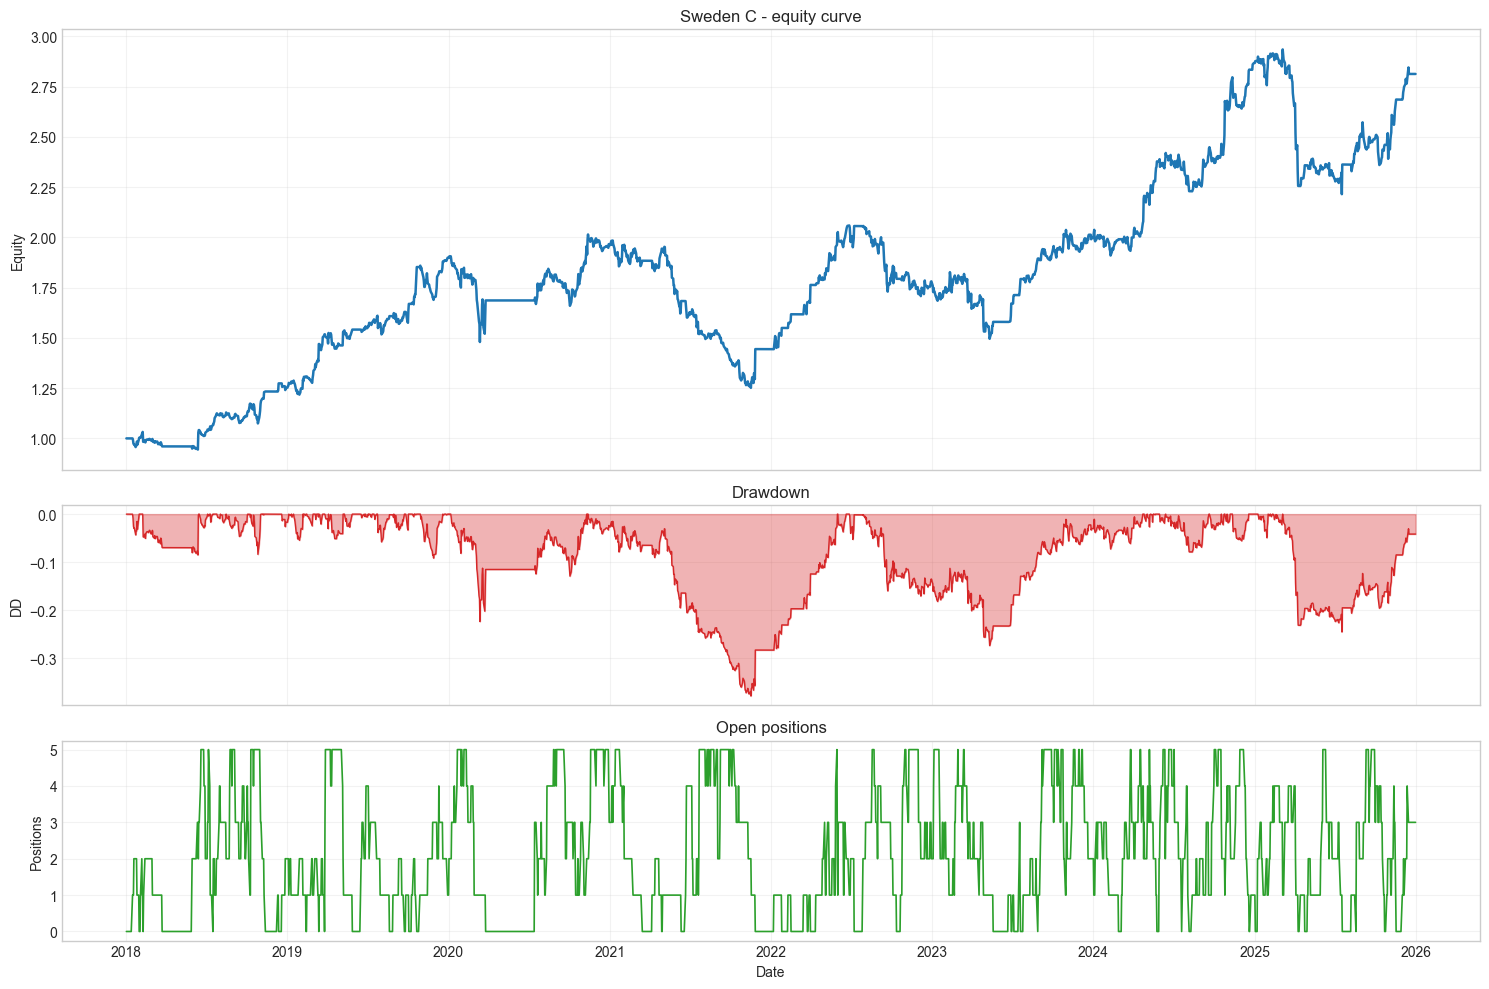

In [21]:
eq = equity.copy()
eq['datetime'] = pd.to_datetime(eq['datetime'], errors='coerce')
eq['equity'] = pd.to_numeric(eq['equity'], errors='coerce')
eq['n_open_positions'] = pd.to_numeric(eq.get('n_open_positions'), errors='coerce')
eq = eq.dropna(subset=['datetime', 'equity']).sort_values('datetime')
eq['drawdown'] = eq['equity'] / eq['equity'].cummax() - 1.0

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True, gridspec_kw={'height_ratios': [2.2, 1, 1]})

axes[0].plot(eq['datetime'], eq['equity'], color='#1f77b4', linewidth=1.8)
axes[0].set_title('Sweden C - equity curve')
axes[0].set_ylabel('Equity')

axes[1].fill_between(eq['datetime'], eq['drawdown'], 0, color='#d62728', alpha=0.35)
axes[1].plot(eq['datetime'], eq['drawdown'], color='#d62728', linewidth=1.0)
axes[1].set_title('Drawdown')
axes[1].set_ylabel('DD')

axes[2].plot(eq['datetime'], eq['n_open_positions'], color='#2ca02c', linewidth=1.2)
axes[2].set_title('Open positions')
axes[2].set_ylabel('Positions')
axes[2].set_xlabel('Date')

for ax in axes:
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

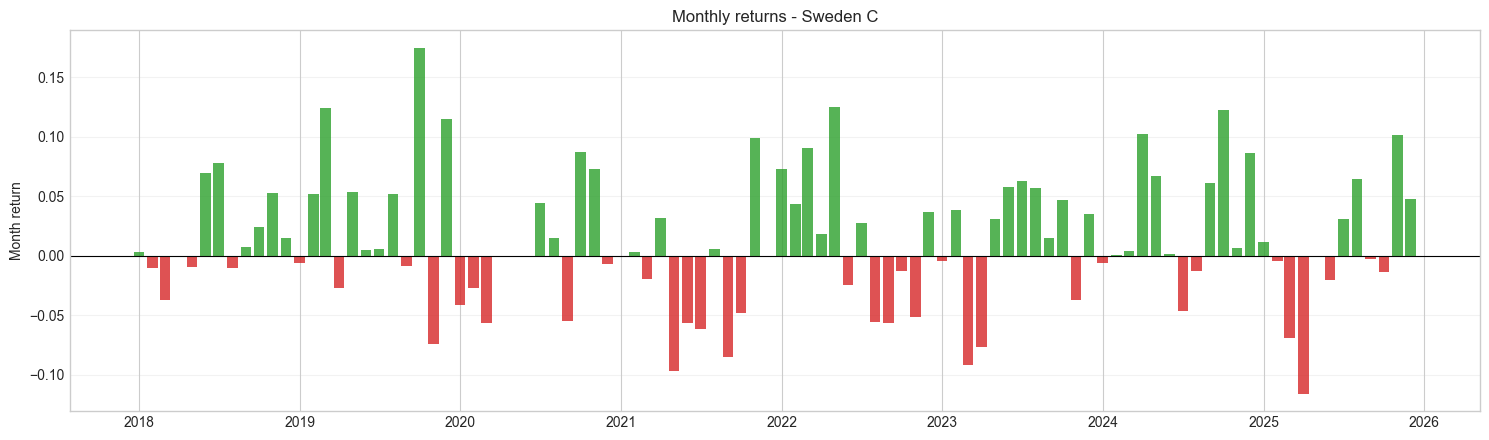

,trade_month,month_return,avg_open_positions,max_open_positions
72,2024-01,-0.006341,2.434783,3
73,2024-02,0.000274,0.952381,2
74,2024-03,0.004262,2.380952,5
75,2024-04,0.102234,3.090909,5
76,2024-05,0.066770,2.347826,5
77,2024-06,0.001689,4.200000,5
78,2024-07,-0.046716,2.608696,5
79,2024-08,-0.012915,1.045455,3
80,2024-09,0.061107,1.952381,4
81,2024-10,0.122583,3.652174,5


In [22]:
m = monthly.copy()
if not m.empty:
    m['trade_month_dt'] = pd.to_datetime(m['trade_month'], format='%Y-%m', errors='coerce')
    m['month_return'] = pd.to_numeric(m['month_return'], errors='coerce')
    colors = np.where(m['month_return'] >= 0, '#2ca02c', '#d62728')

    fig, ax = plt.subplots(figsize=(15, 4.5))
    ax.bar(m['trade_month_dt'], m['month_return'], width=24, color=colors, alpha=0.8)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title('Monthly returns - Sweden C')
    ax.set_ylabel('Month return')
    ax.grid(True, axis='y', alpha=0.25)
    plt.tight_layout()
    plt.show()

    display(m[['trade_month', 'month_return', 'avg_open_positions', 'max_open_positions']].tail(24))
else:
    print('No monthly returns available.')

## Graphes trades et exits

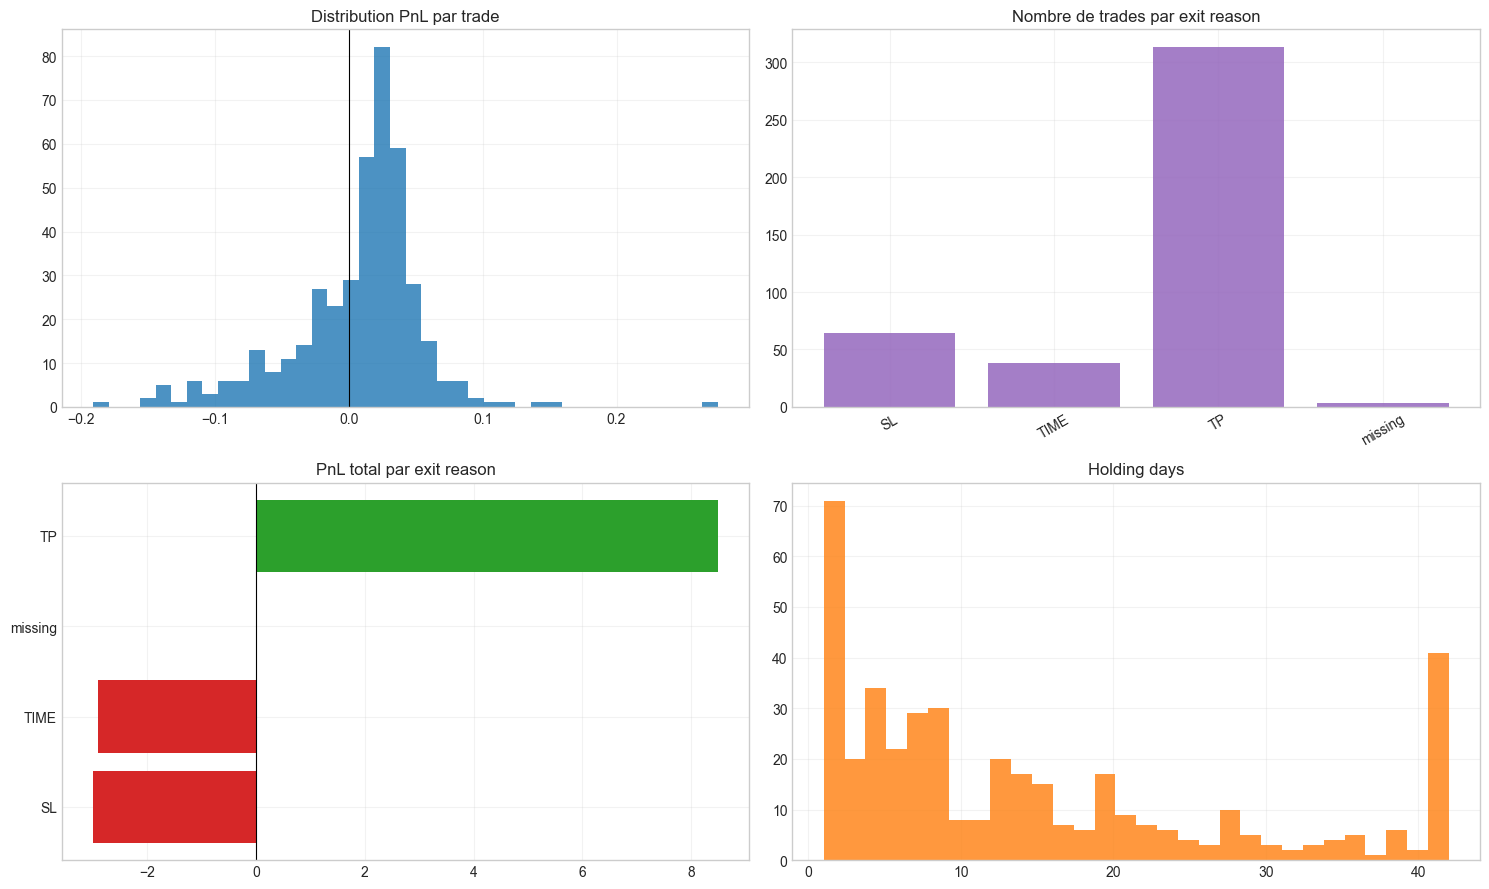

In [23]:
tr = enriched.copy()
tr['entry_datetime'] = pd.to_datetime(tr['entry_datetime'], errors='coerce')
tr['pnl'] = pd.to_numeric(tr['pnl'], errors='coerce')
tr['holding_days'] = pd.to_numeric(tr.get('holding_days'), errors='coerce')
closed = tr.dropna(subset=['pnl']).copy()

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

axes[0, 0].hist(closed['pnl'], bins=40, color='#1f77b4', alpha=0.8)
axes[0, 0].axvline(0, color='black', linewidth=0.8)
axes[0, 0].set_title('Distribution PnL par trade')

exit_counts = tr['exit_reason_bucket'].fillna('missing').value_counts().sort_index()
axes[0, 1].bar(exit_counts.index.astype(str), exit_counts.values, color='#9467bd', alpha=0.85)
axes[0, 1].set_title('Nombre de trades par exit reason')
axes[0, 1].tick_params(axis='x', rotation=30)

exit_pnl = tr.groupby(tr['exit_reason_bucket'].fillna('missing'))['pnl'].sum().sort_values()
axes[1, 0].barh(exit_pnl.index.astype(str), exit_pnl.values, color=np.where(exit_pnl.values >= 0, '#2ca02c', '#d62728'))
axes[1, 0].axvline(0, color='black', linewidth=0.8)
axes[1, 0].set_title('PnL total par exit reason')

axes[1, 1].hist(tr['holding_days'].dropna(), bins=30, color='#ff7f0e', alpha=0.8)
axes[1, 1].set_title('Holding days')

for ax in axes.ravel():
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

## Analyse par segment

Change `SEGMENT_COL` pour explorer d'autres axes : `market_regime`, `stress_bucket`, `corr_type`, `beta_stability_bucket`, `abs_z_entry_quintile`, `z_speed_ewma_quintile`, `exit_reason_bucket`, etc.

,segment_type,config_name,segment_value,nb_trades,win_rate,avg_pnl,median_pnl,total_pnl,avg_holding_days,median_holding_days,avg_mae,avg_mfe,tp_rate,sl_rate,timeout_rate,expectancy,profit_factor,trade_sharpe_like,contribution_to_total_pnl,contribution_to_total_trades
0,market_regime,best_plus_regime_filter,neutral,265.0,0.674242,0.006313,0.018031,1.666633,14.924242,10.5,-0.031271,0.024766,0.762264,0.128302,0.105660,0.006313,1.401986,0.123894,0.643759,0.633971
3,market_regime,best_plus_regime_filter,trending,71.0,0.623188,0.006800,0.018155,0.469206,13.608696,8.0,-0.029054,0.026207,0.690141,0.225352,0.056338,0.006800,1.421273,0.138411,0.181237,0.169856
2,market_regime,best_plus_regime_filter,stress_trending,29.0,0.724138,0.011336,0.021846,0.328751,12.689655,8.0,-0.023966,0.024379,0.793103,0.137931,0.068966,0.011336,2.129358,0.335068,0.126985,0.069378
1,market_regime,best_plus_regime_filter,stress,53.0,0.584906,0.002346,0.020185,0.124317,15.792453,12.0,-0.035028,0.024893,0.735849,0.188679,0.075472,0.002346,1.122597,0.045975,0.048019,0.126794


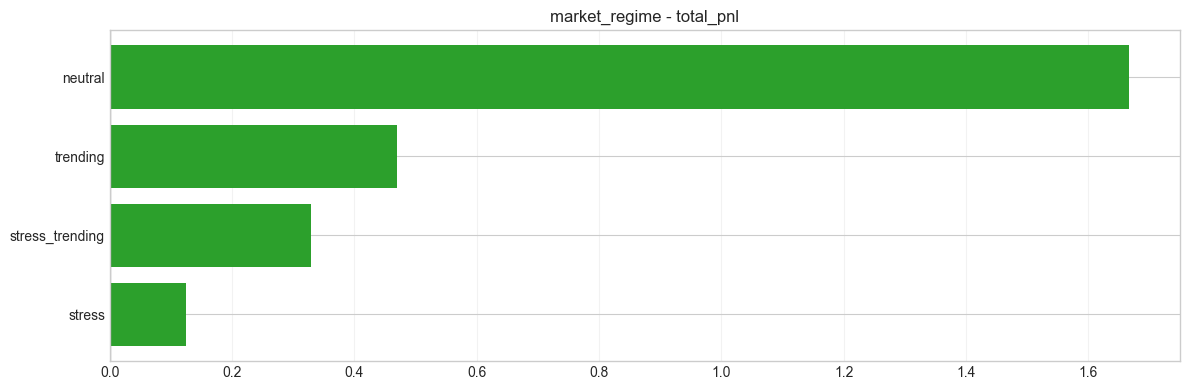

In [24]:
def show_segment(segment_col: str, min_trades: int = 3, sort_by: str = 'total_pnl') -> pd.DataFrame:
    if segment_col not in enriched.columns:
        raise KeyError(f'{segment_col} is not in enriched trades columns.')

    summary = summarize_edge_by_segment(enriched, (segment_col,))
    if summary.empty:
        print('No segment summary available.')
        return summary

    summary = summary[pd.to_numeric(summary['nb_trades'], errors='coerce') >= min_trades].copy()
    summary = summary.sort_values(sort_by, ascending=False)
    display(summary)

    plot_df = summary.sort_values(sort_by, ascending=True).tail(20)
    fig, ax = plt.subplots(figsize=(12, max(4, 0.42 * len(plot_df))))
    values = pd.to_numeric(plot_df[sort_by], errors='coerce')
    ax.barh(plot_df['segment_value'].astype(str), values, color=np.where(values >= 0, '#2ca02c', '#d62728'))
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{segment_col} - {sort_by}')
    ax.grid(True, axis='x', alpha=0.25)
    plt.tight_layout()
    plt.show()
    return summary


SEGMENT_COL = 'market_regime'
segment_summary = show_segment(SEGMENT_COL, min_trades=3, sort_by='total_pnl')

In [25]:
for col in ['stress_bucket', 'trending_bucket', 'corr_type', 'beta_stability_bucket', 'abs_z_entry_quintile', 'z_speed_ewma_quintile', 'exit_reason_bucket']:
    if col in enriched.columns:
        display(Markdown(f'### {col}'))
        display(summarize_edge_by_segment(enriched, (col,)).sort_values('total_pnl', ascending=False))

### stress_bucket

,segment_type,config_name,segment_value,nb_trades,win_rate,avg_pnl,median_pnl,total_pnl,avg_holding_days,median_holding_days,avg_mae,avg_mfe,tp_rate,sl_rate,timeout_rate,expectancy,profit_factor,trade_sharpe_like,contribution_to_total_pnl,contribution_to_total_trades
0,stress_bucket,best_plus_regime_filter,non_stress,336.0,0.663664,0.006414,0.018098,2.135839,14.651652,9.0,-0.030812,0.025065,0.747024,0.148810,0.095238,0.006414,1.406070,0.126984,0.824997,0.803828
1,stress_bucket,best_plus_regime_filter,stress,82.0,0.634146,0.005525,0.021333,0.453067,14.695122,11.0,-0.031116,0.024711,0.756098,0.170732,0.073171,0.005525,1.347146,0.120992,0.175003,0.196172


### trending_bucket

,segment_type,config_name,segment_value,nb_trades,win_rate,avg_pnl,median_pnl,total_pnl,avg_holding_days,median_holding_days,avg_mae,avg_mfe,tp_rate,sl_rate,timeout_rate,expectancy,profit_factor,trade_sharpe_like,contribution_to_total_pnl,contribution_to_total_trades
0,trending_bucket,best_plus_regime_filter,non_trending,318.0,0.659306,0.005650,0.018296,1.790949,15.069401,11.0,-0.031899,0.024787,0.757862,0.138365,0.100629,0.005650,1.347081,0.110982,0.691778,0.760766
1,trending_bucket,best_plus_regime_filter,trending,100.0,0.653061,0.008142,0.019176,0.797957,13.336735,8.0,-0.027548,0.025666,0.720000,0.200000,0.060000,0.008142,1.567990,0.180860,0.308222,0.239234


### corr_type

...

,segment_type,config_name,segment_value,nb_trades,win_rate,avg_pnl,median_pnl,total_pnl,avg_holding_days,median_holding_days,avg_mae,avg_mfe,tp_rate,sl_rate,timeout_rate,expectancy,profit_factor,trade_sharpe_like,contribution_to_total_pnl,contribution_to_total_trades
1,abs_z_entry_quintile,best_plus_regime_filter,abs_z_q2,83.0,0.756098,0.010154,0.019153,0.832610,12.414634,7.0,-0.026969,0.022564,0.831325,0.108434,0.048193,0.010154,1.913927,0.255432,0.321607,0.198565
0,abs_z_entry_quintile,best_plus_regime_filter,abs_z_q1,84.0,0.726190,0.008656,0.019759,0.727098,14.750000,10.5,-0.029627,0.024598,0.857143,0.059524,0.083333,0.008656,1.639099,0.187499,0.280852,0.200957
2,abs_z_entry_quintile,best_plus_regime_filter,abs_z_q3,84.0,0.698795,0.006965,0.017887,0.578101,14.530120,9.0,-0.029896,0.023707,0.785714,0.130952,0.071429,0.006965,1.480437,0.155233,0.223299,0.200957
3,abs_z_entry_quintile,best_plus_regime_filter,abs_z_q4,83.0,0.658537,0.005175,0.023104,0.424336,15.219512,12.0,-0.034331,0.026879,0.734940,0.132530,0.120482,0.005175,1.272005,0.095720,0.163905,0.198565
4,abs_z_entry_quintile,best_plus_regime_filter,abs_z_q5,84.0,0.452381,0.000319,-0.002519,0.026761,16.345238,12.0,-0.033513,0.027199,0.535714,0.333333,0.130952,0.000319,1.015267,0.005260,0.010337,0.200957


### z_speed_ewma_quintile

,segment_type,config_name,segment_value,nb_trades,win_rate,avg_pnl,median_pnl,total_pnl,avg_holding_days,median_holding_days,avg_mae,avg_mfe,tp_rate,sl_rate,timeout_rate,expectancy,profit_factor,trade_sharpe_like,contribution_to_total_pnl,contribution_to_total_trades
3,z_speed_ewma_quintile,best_plus_regime_filter,zspeed_ewma_q4,83.0,0.716049,0.013464,0.022655,1.090597,13.333333,10.0,-0.026367,0.027584,0.759036,0.144578,0.072289,0.013464,2.154322,0.271055,0.421258,0.198565
0,z_speed_ewma_quintile,best_plus_regime_filter,zspeed_ewma_q1,84.0,0.726190,0.011094,0.021736,0.931898,15.547619,11.5,-0.028637,0.026634,0.869048,0.047619,0.083333,0.011094,1.836639,0.236885,0.359958,0.200957
1,z_speed_ewma_quintile,best_plus_regime_filter,zspeed_ewma_q2,83.0,0.743902,0.007625,0.021135,0.625223,14.426829,9.0,-0.029942,0.024092,0.819277,0.096386,0.072289,0.007625,1.533791,0.170049,0.241501,0.198565
4,z_speed_ewma_quintile,best_plus_regime_filter,zspeed_ewma_q5,84.0,0.523810,-0.000269,0.006491,-0.022570,13.988095,7.0,-0.035070,0.024122,0.630952,0.273810,0.095238,-0.000269,0.987050,-0.004664,-0.008718,0.200957
2,z_speed_ewma_quintile,best_plus_regime_filter,zspeed_ewma_q3,84.0,0.583333,-0.000431,0.014958,-0.036242,15.952381,12.0,-0.034159,0.022613,0.666667,0.202381,0.130952,-0.000431,0.977237,-0.009151,-0.013999,0.200957


### exit_reason_bucket

,segment_type,config_name,segment_value,nb_trades,win_rate,avg_pnl,median_pnl,total_pnl,avg_holding_days,median_holding_days,avg_mae,avg_mfe,tp_rate,sl_rate,timeout_rate,expectancy,profit_factor,trade_sharpe_like,contribution_to_total_pnl,contribution_to_total_trades
2,exit_reason_bucket,best_plus_regime_filter,TP,313.0,0.869010,0.027142,0.025792,8.495353,13.341853,10.0,-0.019728,0.030994,1.0,0.0,0.0,0.027142,13.903855,0.904947,3.281445,0.748804
1,exit_reason_bucket,best_plus_regime_filter,TIME,38.0,0.000000,-0.076552,-0.071336,-2.908991,42.000000,42.0,-0.096439,0.011592,0.0,0.0,1.0,-0.076552,0.000000,-1.865323,-1.123637,0.090909
0,exit_reason_bucket,best_plus_regime_filter,SL,64.0,0.015625,-0.046835,-0.033605,-2.997455,4.875000,2.0,-0.046443,0.003613,0.0,1.0,0.0,-0.046835,0.000034,-1.203014,-1.157808,0.153110
3,exit_reason_bucket,best_plus_regime_filter,missing,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.007177


## Sauvegarde optionnelle des outputs du notebook

In [26]:
if SAVE_OUTPUTS:
    run_name = f'{CONFIG_NAME}_{pd.Timestamp(START).strftime("%Y%m%d")}_{pd.Timestamp(END).strftime("%Y%m%d")}'
    out_dir = OUTPUT_DIR / run_name
    out_dir.mkdir(parents=True, exist_ok=True)

    equity.to_csv(out_dir / 'equity.csv', index=False)
    trades.to_csv(out_dir / 'trades.csv', index=False)
    enriched.to_csv(out_dir / 'trades_enriched.csv', index=False)
    monthly.to_csv(out_dir / 'monthly_returns.csv', index=False)
    stats.to_csv(out_dir / 'portfolio_stats.csv', index=False)
    filter_diagnostics.to_csv(out_dir / 'filter_diagnostics.csv', index=False)
    trade_level.to_csv(out_dir / 'trade_level_summary.csv', index=False)
    concentration.to_csv(out_dir / 'concentration_summary.csv', index=False)
    pair_level.to_csv(out_dir / 'pair_level_summary.csv', index=False)

    manifest = {
        'config': config_to_dict(config),
        'start': START,
        'end': END,
        'universe': UNIVERSE,
        'thresholds': {
            'abs_z_extreme_min': thresholds.abs_z_extreme_min,
            'zspeed_ewma_extreme_min': thresholds.zspeed_ewma_extreme_min,
            'beta_stability_degraded_min': thresholds.beta_stability_degraded_min,
            'source_dir': str(thresholds.source_dir),
        },
        'regime_rules': REGIME_RULES_DESCRIPTION,
    }
    (out_dir / 'manifest.json').write_text(json.dumps(manifest, indent=2, default=str), encoding='utf-8')
    print(f'Outputs saved to: {out_dir}')
else:
    print('SAVE_OUTPUTS=False; no files written.')

Outputs saved to: D:\Business\Trading\VSCODE\algo-trading-stat-arb-terminal\data\experiments\notebook_sweden_C_strategy_run\best_plus_regime_filter_20180101_20251231
